This notebook reads data taken from adsbexchange.com and pulls values of interest into a pandas dataframe for further ananlysis and visualization.  

The data meant for this script is the readsb-hist files available at https://samples.adsbexchange.com/index.html.  Each data file is a snapshot of all airborne traffic at a specific UTC time.  The file naming convention is HHMMSSZ.json.gz and each file is stored in a folder corresponding to the date the data was recieved. For example, there is a 2025/01/01 folder for the first day of the year and it contains files 000000Z.json.gz, 000005Z.json.gz, 000010Z.json.gz,..., 235955Z.json.gz. And there is a folder for the next day 2025/01/02 containing files with the same names (000000Z.json.gz,... 235955Z.json.gz)  The adsbexchange shares the data on the first day of each month for free, this is current and goes back several years. Getting data for other days requires payment.  The data can be downloaded from their website or pulled from their AWS S3 buckets.  A script for pulling from the S3 buckets should exist in the github repo this notebook is contained in. 

The data read from a single readsb-hist file should be a dictionary with the following structure:
    
    data = {"now": utc time in unix epoch time  
            "messages": number of adsb messages recieved in this snapshot  
            "aircraft": list of dictionaries where each dict represents a single aircraft   
                         with key/values as described at https://www.adsbexchange.com/version-2-api-wip/  
            }
        
For example a single file would return a dictionary like the following: 
    
    data = { "now" : 1735689599.001,
             "messages" : 1112492492,
             "aircraft" : [           
                           {"hex":"86d244","type":"other","flight":"ANA101","r":"JA813A","t":"B788","alt_baro":39975,"gs":476.0, ...}
                           {"hex":"a1d8fd","type":"other","flight":"UAL837","r":"N218UA","t":"B772","alt_baro":36000,"gs":481.0, ...}
                           {"hex":"a670a3","type":"adsb_icao","flight":"DAL7","r":"N514DN","alt_baro":40000,"alt_geom":38750,...} 
                                                                       ...
                                                                       ...                  
                           ]

If a value was not recieved in a transmission for any reason, it is simply omitted from that aircraft dictionary.  For example, in the third 
aircraft dict in the example above the type 't' is missing but the geometric altitude ("alt_geom") is included. The first two aircraft dictionaries have "t" key-value pairs, but do not have "alt_geom" 

In [1]:
## Import needed modules
import json
import gzip
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import time

In [3]:
## Define Inputs
## The script below assumes you are reading in files from one specific date. The files will be named according to the convention above.
## Define starting and ending UTC times in the range of 000000Z to 235955Z. 

start = [0,0,0] # define UTC time for first file to be read [hh, mm, ss] i.e. the first file to be read and processed will be hhmmssZ.json.gz
end = [0,59,55] # define UTC time for last file to be read [hh, mm, ss]
inc = 5         # increment of time between snapshots/files.  This is normally 5 seconds, but hi-res data is avialable in 2 second intervals

# Change this to the path of your adsb files
path = "C:/Users/jacob/Documents/python_work/aia_work/test_data/"

# Data will be read into the following dictionary and then converted to a pandas dataframe
# The key values are a selection of what's available in the readsb-hist data files and the nameing conventions are those used by adsbexchange 
# See API here: for a complete list of potential key values.  For now I've selected a few that seem relevant
# The item values for each key will be lists that store the relevant data
processed_data = { 'flight': [],       #Flight name/number
                   'hex': [],          #ICAO identifier of the aircraft
                   't': [],            #Type of aircraft
                   'alt_baro': [],     #Barometric altitude
                   'alt_geom': [],     #Geometric altitude
                   'baro_rate': [],    #Barometric climb/descent rate
                   'geom_rate': [],    #Geometric climb/descent rate
                   'lat': [],          #Latitude
                   'lon': [],          #Longitude
                   'track': [],        #Ground track
                   'track_rate': [],   #Ground track rate of change
                   'ias': [],          #Indicated Airspeed
                   'gs': [],           #Ground speed
                   'mag_heading': [],  #Magnetic heading
                   'wd': [],           #Wind direction
                   'ws': [],           #Wind speed
                   'oat': [],          #Outside air temperature
                   'time': [],         #UTC time
                   }

In [5]:
## Function definitions

## Read the json.gz files and return the data as a python dictionary
def read_data(filename):
    with gzip.open(filename, 'rt', encoding='utf-8') as f:
        data = json.load(f) #read json data into a dictionary
    return data

## Take the data dictionary and pull values into the processed_data list defined above
def process_data(data):
    now = data['now'] #get the time stamp for this set of data in unix epoch time
    ac_data = data['aircraft'] #get a list of dictionaries that contain flight data for all airborne aircraft at the time stamp.  
                               #each dictionary in the list contains the data for one aircraft

    ## Convert the time to a readable formatted time string
    formatted_utc_time = time.strftime('%H:%M:%S', time.gmtime(now))

    for ac_dict in ac_data:
        ## Make sure the flight has an id and aircraft type
        if 'hex' not in ac_dict.keys() or 't' not in ac_dict.keys(): 
            continue # if not, just skip this aircraft for now

        # Pull values from data into dictionary that will be used to create dataframe
        for key in processed_data.keys():
            if key in ac_dict:                                  # Make sure this aircraft has the data we are trying to pull
                processed_data[key].append(ac_dict[key])
            elif key == 'time':                                 # Time is stored separaely from the aircraft dictionary
                processed_data[key].append(formatted_utc_time)
            else:
                processed_data[key].append(None)                # If the value doesn't exist, append None to keep all lists equal length
            
def calculate_track(lat1, lon1, lat2, lon2):
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    delta_lon = lon2_rad - lon1_rad
    x = np.sin(delta_lon) * np.cos(lat2_rad)
    y = np.cos(lat1_rad) * np.sin(lat2_rad) - (np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(delta_lon))

    track = np.arctan2(x, y)
    track_deg = np.degrees(track)
    
    return track_deg % 360

In [7]:
## Process data by looping through re-adsb data files and output csv file
# If reloading the same data, skip this cell and read in the csv file in the next cell
# This loops through all the files defined by the start and end zulu times and reads the data into processed_data dictionary that we defined
# earlier in the 'inputs' cells
for hh in range(start[0], end[0]+1):
    for mm in range(start[1], end[1]+1):
        for ss in range(start[2], end[2]+1, 5):
            zulu_time = str(hh).zfill(2)+str(mm).zfill(2)+str(ss).zfill(2)+'Z'  #Get the zulu time as a 6 digit string
            file_name = zulu_time+'.json.gz'                                    #append .json.gz to get the filename
            file_path = path+file_name                                          #append filename to folder path to get the complete path to the file
            data = read_data(file_path)                                         #read the json data into a python dictionary
            process_data(data)                                                  #process the data - pull values into the processed_data dict

## Convert data to pandas dataframe and sort by aircraft hex id and time to group data by individual aircraft with data points organized by time 
df = pd.DataFrame(processed_data)
sorted_df = df.sort_values(['hex','time'], ascending=[False,True])

#When an aircraft is on the ground, alt_baro contains a string, "ground"
# replace with 0 or nan to keep dtype consistent
sorted_df = sorted_df.replace('ground', np.nan) 
sorted_df.to_csv('processed_adsb_data.csv')

C:\Users\jacob\AppData\Local\Temp\ipykernel_26524\3980829108.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sorted_df = sorted_df.replace('ground', np.nan)


In [9]:
sorted_df = pd.read_csv('processed_adsb_data.csv')
sorted_df['alt_baro'] = sorted_df['alt_baro'].astype(float)  #for some reason some values come in as strings, convert back to float
sorted_df.head()

,Unnamed: 0,flight,hex,t,alt_baro,alt_geom,baro_rate,geom_rate,lat,lon,track,track_rate,ias,gs,mag_heading,wd,ws,oat,time
0,14346,NaN,e94c8f,B738,38000.0,NaN,60.0,NaN,-10.993776,-63.022396,348.0,NaN,NaN,430.0,NaN,NaN,NaN,NaN,00:00:04
1,23039,NaN,e94c8f,B738,38000.0,NaN,60.0,NaN,-10.975891,-63.026196,348.0,NaN,NaN,430.0,NaN,NaN,NaN,NaN,00:00:09
2,31727,NaN,e94c8f,B738,38000.0,NaN,0.0,NaN,-10.970169,-63.027428,348.0,NaN,NaN,438.0,NaN,NaN,NaN,NaN,00:00:14
3,40403,NaN,e94c8f,B738,38000.0,NaN,60.0,NaN,-10.960352,-63.029480,348.0,NaN,NaN,430.0,NaN,NaN,NaN,NaN,00:00:19
4,49065,NaN,e94c8f,B738,38000.0,NaN,0.0,NaN,-10.954285,-63.030788,348.0,NaN,NaN,430.0,NaN,NaN,NaN,NaN,00:00:24


In [13]:
## Calculate additional values

# Group by aircraft ID ('hex') to make sure values are calculated per aircraft
grouped_by_hex_df = sorted_df.groupby('hex')

## Calculate Track
# Temporarily create a next_lat and next_lon columns shifted one time step ahead of the original lat and lon columns
sorted_df['next_lat'] = grouped_by_hex_df['lat'].shift(-1)
sorted_df['next_lon'] = grouped_by_hex_df['lon'].shift(-1)
mask = sorted_df['next_lat'].notna() #last value in each next_lat and next_lon column will be NaN due to the shift
# Use the shifted lats and lons and original lats and lons to calculate track
sorted_df.loc[mask, 'calc_track'] = calculate_track(sorted_df.loc[mask, 'lat'],
                                                    sorted_df.loc[mask, 'lon'],
                                                    sorted_df.loc[mask, 'next_lat'],
                                                    sorted_df.loc[mask, 'next_lon']
                                                   )
# Clean up by dropping the temporary next lat and lon columns
sorted_df = sorted_df.drop(columns=['next_lat', 'next_lon'])

## Calculate baro_rate, geom_rate, track_rate, heading_rate, and acceleration 
# baro_rate, geom_rate, and track_rate are included in the original data if available in the adsb_transmission
# but sometimes these not available for different aircraft and sensors
# a rough rate can be calculated by taking the difference in values divided by the time step in transmissions/readings
sorted_df['calc_baro_rate'] = grouped_by_hex_df['alt_baro'].diff()/inc
sorted_df['calc_geom_rate'] = grouped_by_hex_df['alt_geom'].diff()/inc
sorted_df['calc_track_rate'] = grouped_by_hex_df['track'].diff()/inc
sorted_df['calc_heading_rate'] = grouped_by_hex_df['mag_heading'].diff()/inc

In [49]:
## Find the most common aircraft types in this data sample
unique_ids_df = sorted_df.drop_duplicates(subset='hex')  # Drop duplicates of hex id to get a list where each aircraft is captured once
ac_type_counts = unique_ids_df['t'].value_counts()       # Get the value counts of 't' which is the type of aircraft
top_types = ac_type_counts[ac_type_counts > 50]         # Limit the list to aircraft types correspond to more than some threshold number of flights
filtered_type_df = sorted_df[sorted_df['t'].isin(top_types.keys())]  #filter the full dataframe by the most common types found above

print(top_types) # print the top types to use for plotting below

t
B738    1577
A320    1260
A21N     695
A321     683
B38M     669
C172     618
A20N     600
E75L     434
B737     410
B77W     382
B739     325
B789     322
A319     273
A333     267
A359     258
P28A     258
C208     229
B763     228
B788     181
TWR      169
B39M     163
C182     159
B77L     143
B752     142
B772     124
A332     120
CRJ9     119
CRJ7     116
BCS3     116
PC12     109
AS50     107
AT76     101
DH8D     101
A388      98
B407      94
BE20      91
E190      89
EC35      85
B744      83
R44       83
C150      80
SERV      77
EC30      70
M20P      70
B78X      70
CRJ2      66
A339      61
SR22      60
E170      57
A35K      56
EC45      55
B190      54
B748      52
BE35      52
B06       52
Name: count, dtype: int64


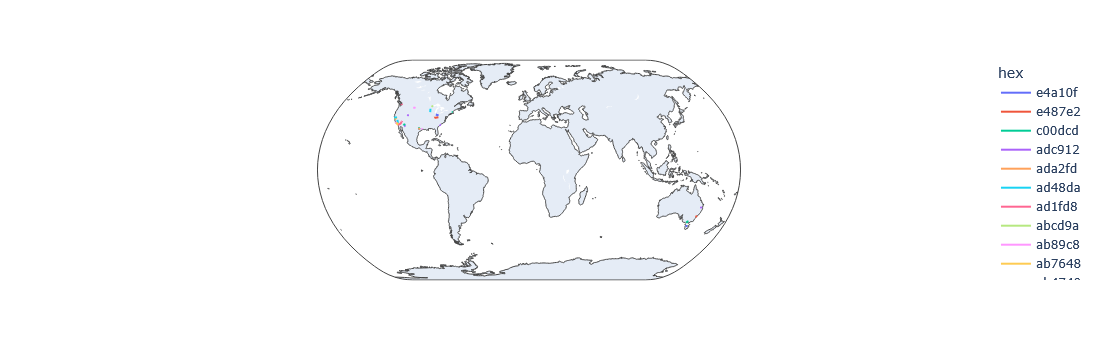

In [51]:
## Plot the flights for a single type on a world map

## Choose an aircraft type from the list printed in the previous cell above
ac_type = 'SR22' 

## Create a line plot showing ground tracks
fig1 = px.line_geo(filtered_type_df[filtered_type_df['t'] == ac_type],
                                      lat="lat",
                                      lon="lon",
                                      color="hex",
                                      projection='natural earth',
                                      hover_name="hex",)
fig1.show()

In [53]:
## Calculate mean, max, min, std dev, and mode

filtered_type_df = filtered_type_df.dropna() # drop any rows where a NaN exists in any column
                                             # this will also remove a good bit of other real value data as well 
# todo: remove columns of values that won't be used, replace track, track_rate, baro_rate, geom_rate with calculated values where they are NaNs

subset = filtered_type_df.drop(['flight', 'hex', 'time'], axis=1) # Drop columns with no numerical values
grouped_by_type_df = subset.groupby('t')

#Calculate stats
maxes = grouped_by_type_df.max()
mins = grouped_by_type_df.min()
means = grouped_by_type_df.mean()
stds = grouped_by_type_df.std()
modes = grouped_by_type_df.apply(lambda x: x[x != 0].mode().iloc[0])

C:\Users\jacob\AppData\Local\Temp\ipykernel_26524\354611166.py:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



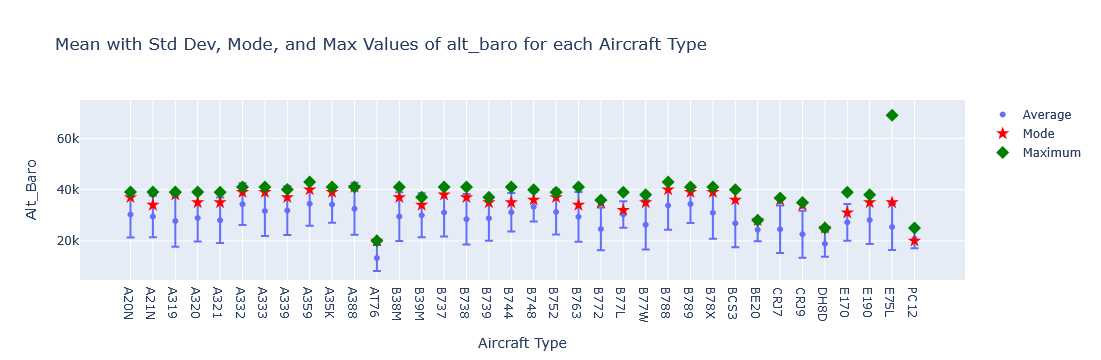

In [55]:
## Plot statistics for various values
y_var_name = 'alt_baro'  ## Choose a variable to plot mean, max, mode, and std dev
x = list(means[y_var_name].keys()) # get aircraft types for x axis

# Make scatter plots
trace_mean = go.Scatter(x=x,
                        y=means[y_var_name].tolist(),
                        mode='markers',
                        name='Average',
                        error_y=dict( type='data',
                                     array=stds[y_var_name].tolist(),
                                     visible=True                        
                                    )
                       )

trace_mode = go.Scatter(x=x,
                        y=modes[y_var_name].tolist(),
                        mode='markers',
                        name='Mode',
                        marker=dict(symbol='star', size=10, color='red')
                       )


trace_max = go.Scatter(x=x,
                       y=maxes[y_var_name].tolist(),
                       mode='markers',    
                       name='Maximum',
                       marker=dict(symbol='diamond', size=10, color='green')
                      )                        

stats_fig = go.Figure(data=[trace_mean, trace_mode, trace_max])

stats_fig.update_layout(
    title=f"Mean with Std Dev, Mode, and Max Values of {y_var_name} for each Aircraft Type",
    xaxis_title='Aircraft Type',
    yaxis_title=y_var_name.title()
)

stats_fig.show()